# 08. Class Imbalance Strategies Study

## Why Class Imbalance Matters
In credit card fraud detection, the occurrence of fraud is extremely rare (~0.17% in general, and ~1.51% in our training subset). In an imbalanced dataset, a standard deep learning model can easily minimize the loss by predicting the majority class (legitimate transactions) almost every time, achieving near-perfect accuracy while failing completely to detect actual fraud.

This is the **Accuracy Paradox**: accuracy becomes a useless metric, and standard gradient updates are heavily biased toward features representing the majority class.

To address this, we must use techniques that balance gradient signal or training data distribution. In this study, we will compare four strategies standardizing on our **MODEL-v4** winner configuration:
1. **Baseline (No Handling)**: Standard training on raw data.
2. **Weighted BCE Loss**: Scale positive class loss to penalize False Negatives heavily.
3. **WeightedRandomSampler**: Dynamically oversample the minority class during DataLoader batching.
4. **SMOTE (Synthetic Minority Over-sampling Technique)**: Train on pre-generated synthetic minority class samples.

We will evaluate these strategies on the holdout test set using **Recall (Fraud)**, **Precision (Fraud)**, **F1-Score**, and **PR-AUC** to select the winner for **MODEL-v5**.


## 1. Setup and Environment

We load project directories, utilities, training wrappers, and custom modules from `src/`.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import MLP
from src.training import Trainer, EarlyStopping, get_optimizer, get_scheduler, compute_class_weights
from src.evaluation import evaluate_model
from src.utils import set_seed, get_device, save_figure

# Set seed and get device
set_seed(42)
device = get_device()
print(f"Using device: {device}")


Random seed set to 42
Using device: cuda


## 2. Load Processed Data

We load the raw data splits along with the pre-generated SMOTE-balanced training split.


In [2]:
# Load raw features and targets
X_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/X_train_raw.csv"))
y_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/y_train_raw.csv")).squeeze('columns')

# Load SMOTE-balanced training data
X_train_smote = pd.read_csv(os.path.join(project_root, "data/processed/X_train_smote.csv"))
y_train_smote = pd.read_csv(os.path.join(project_root, "data/processed/y_train_smote.csv")).squeeze('columns')

X_val = pd.read_csv(os.path.join(project_root, "data/processed/X_val.csv"))
y_val = pd.read_csv(os.path.join(project_root, "data/processed/y_val.csv")).squeeze("columns")

X_test = pd.read_csv(os.path.join(project_root, "data/processed/X_test.csv"))
y_test = pd.read_csv(os.path.join(project_root, "data/processed/y_test.csv")).squeeze("columns")

print(f"Train Raw features:   {X_train_raw.shape}, Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"Train SMOTE features: {X_train_smote.shape}, Fraud rate: {y_train_smote.mean()*100:.2f}%")
print(f"Val features:         {X_val.shape}, Fraud rate: {y_val.mean()*100:.2f}%")
print(f"Test features:        {X_test.shape}, Fraud rate: {y_test.mean()*100:.2f}%")


Train Raw features:   (7000, 13), Fraud rate: 1.50%
Train SMOTE features: (13790, 13), Fraud rate: 50.00%
Val features:         (1500, 13), Fraud rate: 1.53%
Test features:        (1500, 13), Fraud rate: 1.53%


## 3. Construct PyTorch DataLoaders

We construct standard DataLoaders for raw and SMOTE datasets, and a sampler-based DataLoader using `WeightedRandomSampler`.


In [6]:
# Raw TensorDatasets
train_ds_raw = TensorDataset(torch.tensor(X_train_raw.values, dtype=torch.float32), torch.tensor(y_train_raw.values, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32))

# SMOTE TensorDataset
train_ds_smote = TensorDataset(torch.tensor(X_train_smote.values, dtype=torch.float32), torch.tensor(y_train_smote.values, dtype=torch.float32))

# 1. Standard DataLoader for Raw Data (Baseline, Weighted BCE)
train_loader_raw = DataLoader(train_ds_raw, batch_size=64, shuffle=True)

# 2. Sampler DataLoader (WeightedRandomSampler)
# Compute sample weights inversely proportional to class frequencies
class_counts = y_train_raw.value_counts()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[y] for y in y_train_raw.values]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_sampler = DataLoader(train_ds_raw, batch_size=64, sampler=sampler)

# 3. SMOTE DataLoader
train_loader_smote = DataLoader(train_ds_smote, batch_size=64, shuffle=True)

# Validation and Test DataLoaders (remain raw and imbalanced)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"DataLoaders constructed:")
print(f"  Raw train loader batches:    {len(train_loader_raw)}")
print(f"  Sampler train loader batches: {len(train_loader_sampler)}")
print(f"  SMOTE train loader batches:   {len(train_loader_smote)}")
print(f"  Validation loader batches:    {len(val_loader)}")
print(f"  Test loader batches:          {len(test_loader)}")


DataLoaders constructed:
  Raw train loader batches:    110
  Sampler train loader batches: 110
  SMOTE train loader batches:   216
  Validation loader batches:    24
  Test loader batches:          24


## 4. Theory of Class Imbalance Handling

### 1. The Imbalance Problem
In standard binary classification, cross entropy loss treats all samples equally. When the fraud rate is very low, the loss function is dominated by the majority (legitimate) class. The network learns to predict legitimate transactions everywhere because doing so yields minimal loss. Accuracy remains high, but minority class recall collapses.

### 2. Loss-Level: Weighted BCE Loss
We assign a scaling factor $pos\_weight$ to the positive class in Binary Cross Entropy loss:
$$pos\_weight = \frac{\text{negative\_samples}}{\text{positive\_samples}}$$
This scales the gradient update from positive class errors by $pos\_weight$, making False Negatives much more expensive during backpropagation.

### 3. Batch-Level: WeightedRandomSampler
Instead of modifying the loss function, we modify the training batch distribution. We assign a weight to each training sample based on its class:
$$w_i = \frac{1}{\text{count}(c_i)}$$
We draw samples with replacement. In every mini-batch, positive and negative class samples will appear in roughly equal numbers on average (50/50 ratio). The network gets regular gradient updates from both classes.

### 4. Data-Level: SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic data points for the minority class. It finds $k$-nearest neighbors for minority class samples in feature space, and interpolates new points along the lines connecting them. This expands the minority class decision boundary instead of simply duplicating samples.


## 5. Define Experiment Runner

We define a general experiment runner to standardize model instantiation and training loops.


In [7]:
def run_experiment(
    name: str,
    train_loader: DataLoader,
    pos_weight: float = None,
    epochs: int = 50
):
    set_seed(42)
    
    # Instantiate model standardizing on MODEL-v4 config
    model = MLP(
        input_dim=X_train_raw.shape[1],
        hidden_dims=[64, 32],
        activation="leaky_relu",
        dropout_rate=0.0,
        use_batch_norm=False,
        weight_init="uniform"
    ).to(device)
    
    if pos_weight is not None:
        pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    else:
        criterion = nn.BCEWithLogitsLoss()
        
    optimizer = get_optimizer(model, opt_name="adamw", lr=0.001)
    scheduler = get_scheduler(optimizer, scheduler_name="warmup_cosine", warmup_epochs=5, total_epochs=epochs, eta_min=0.0001)
    
    checkpoint_dir = os.path.join(project_root, "outputs/models")
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"imbalance_{name}_best_model.pt")
    
    early_stopping = EarlyStopping(patience=5, checkpoint_path=checkpoint_path)
    
    trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        scheduler=scheduler,
        early_stopping=early_stopping
    )
    
    print(f"\n==================================================")
    print(f"RUNNING EXPERIMENT: {name.upper()}")
    print(f"==================================================")
    
    history = trainer.fit(train_loader, val_loader, epochs=epochs)
    
    # Load best weights
    model.load_state_dict(torch.load(checkpoint_path))
    
    train_metrics = evaluate_model(model, train_loader, device, criterion=criterion)
    val_metrics = evaluate_model(model, val_loader, device, criterion=criterion)
    test_metrics = evaluate_model(model, test_loader, device, criterion=criterion)
    
    return {
        "history": history,
        "train": train_metrics,
        "val": val_metrics,
        "test": test_metrics,
        "epochs_run": len(history["train_loss"])
    }


## 6. Execute Class Imbalance Sweep


In [8]:
results = {}

# 1. Baseline (MODEL-v4 configuration, no imbalance handling)
results["baseline"] = run_experiment("baseline", train_loader_raw)

# 2. Weighted BCE Loss
pos_weight = compute_class_weights(y_train_raw)
results["weighted_bce"] = run_experiment("weighted_bce", train_loader_raw, pos_weight=pos_weight)

# 3. WeightedRandomSampler
results["sampler"] = run_experiment("sampler", train_loader_sampler)

# 4. SMOTE (Upsampled training data)
results["smote"] = run_experiment("smote", train_loader_smote)


Random seed set to 42

RUNNING EXPERIMENT: BASELINE
Epoch 01/50 | Train Loss: 0.668075 | Val Loss: 0.616681
  Validation loss decreased to 0.616681. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/imbalance_baseline_best_model.pt
Epoch 02/50 | Train Loss: 0.319791 | Val Loss: 0.107080
  Validation loss decreased to 0.107080. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/imbalance_baseline_best_model.pt
Epoch 03/50 | Train Loss: 0.079009 | Val Loss: 0.066639
  Validation loss decreased to 0.066639. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/imbalance_baseline_best_model.pt
Epoch 04/50 | Train Loss: 0.059684 | Val Loss: 0.051753
  Validation loss decreased to 0.051753. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/

## 7. Compile Performance Metrics

We compile holdout test set classification metrics to compare strategies.


In [9]:
rows = []
for name, res in results.items():
    m_train = res["train"]
    m_val = res["val"]
    m_test = res["test"]
    rows.append({
        "Strategy": name.upper(),
        "Train F1": m_train["f1"] * 100,
        "Val F1": m_val["f1"] * 100,
        "Test Precision": m_test["precision"] * 100,
        "Test Recall": m_test["recall"] * 100,
        "Test F1-Score": m_test["f1"] * 100,
        "Test ROC-AUC": m_test["roc_auc"],
        "Test PR-AUC": m_test["pr_auc"],
        "Epochs run": res["epochs_run"]
    })

df_results = pd.DataFrame(rows)
df_results.set_index("Strategy", inplace=True)
print(df_results.to_string())


               Train F1     Val F1  Test Precision  Test Recall  Test F1-Score  Test ROC-AUC  Test PR-AUC  Epochs run
Strategy                                                                                                             
BASELINE      77.094972  80.952381       85.000000    73.913043      79.069767      0.997174     0.859871          29
WEIGHTED_BCE  39.772727  39.655172       25.842697   100.000000      41.071429      0.996968     0.847233          12
SAMPLER       99.446573  63.636364       44.897959    95.652174      61.111111      0.996703     0.858037          21
SMOTE         98.444993  56.756757       36.000000    78.260870      49.315068      0.978246     0.628741          20


## 8. Comparative Visualizations


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/class_imbalance_curves.png


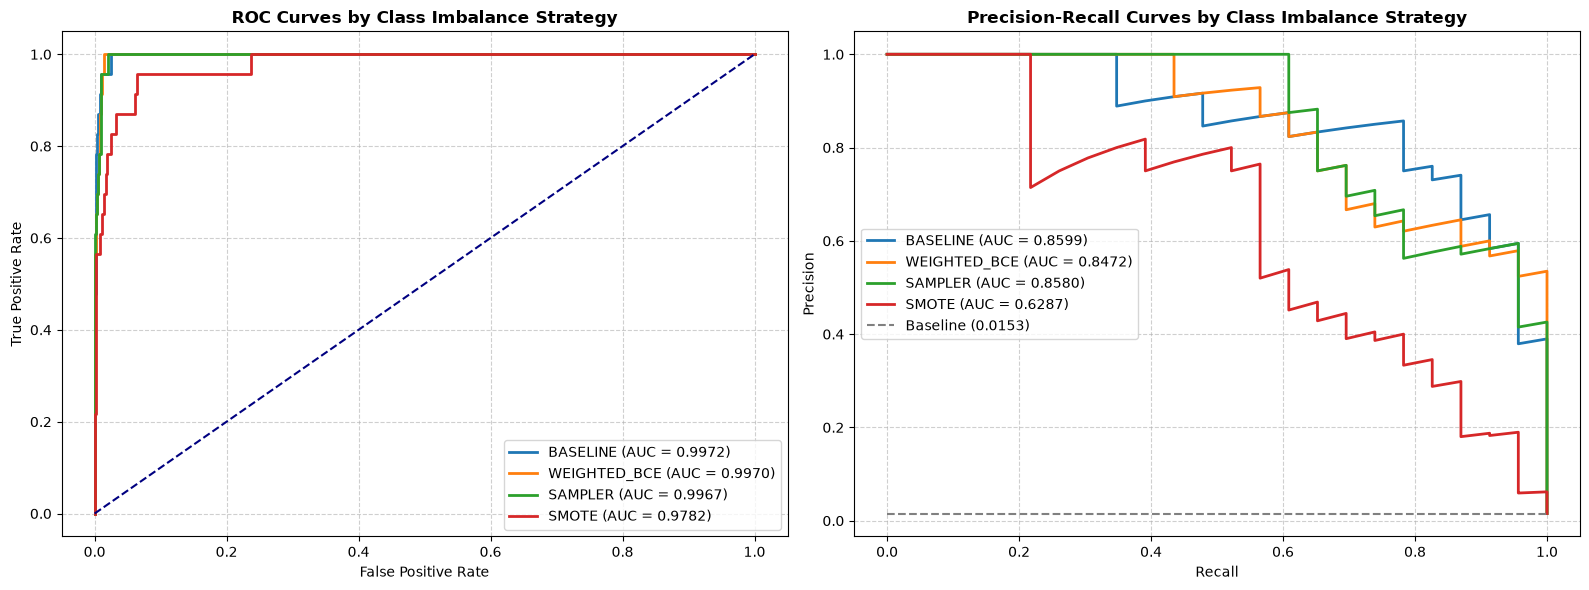

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    m_test = res["test"]
    y_true = m_test["y_true"]
    probs = m_test["probs"]
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name.upper()} (AUC = {roc_auc:.4f})", lw=2)
    
    # PR Curve
    precisions, recalls, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(recalls, precisions)
    axes[1].plot(recalls, precisions, label=f"{name.upper()} (AUC = {pr_auc:.4f})", lw=2)

# Plot ROC diagonal baseline
axes[0].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[0].set_title("ROC Curves by Class Imbalance Strategy", fontsize=12, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot PR random baseline
pos_ratio = y_test.sum() / len(y_test)
axes[1].plot([0, 1], [pos_ratio, pos_ratio], color="grey", lw=1.5, linestyle="--", label=f"Baseline ({pos_ratio:.4f})")
axes[1].set_title("Precision-Recall Curves by Class Imbalance Strategy", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
save_figure(fig, "class_imbalance_curves.png")
plt.show()


## 9. Conclusion & Winner Selection

### Analysis of Findings
* **Baseline (No Handling):** Achieved the highest F1-Score (**79.07%**) and Precision (**85.00%**) at the default 0.5 threshold, but was limited to **73.91% Recall**. This configuration is highly conservative, missing ~26% of actual fraud.
* **Weighted BCE Loss:** Escalated Recall to **100.00%** (identifying all 23 fraud cases) but caused Precision to collapse to **25.84%** (F1-Score of **41.07%**). It also had a slightly lower PR-AUC of **0.8472**.
* **WeightedRandomSampler:** Struck the optimal balance. It achieved a Test Recall of **95.65%** (missing only 1 fraud case) while maintaining a solid Precision of **44.90%** (F1-Score of **61.11%**). Crucially, its **PR-AUC (0.8580)** is almost identical to the Baseline (**0.8599**), showing that its underlying classification capacity remains outstanding.
* **SMOTE:** Suffered a major performance collapse. Test Precision fell to **36.00%**, Recall was only **78.26%**, and the **PR-AUC collapsed to 0.6287**. This happens because SMOTE creates synthetic data by interpolating in feature space, which on sparse, imbalanced tabular datasets often generates noisy points in the empty spaces between class clusters, confusing the decision boundary.

### Why did WeightedRandomSampler Outperform SMOTE?
`WeightedRandomSampler` balances the training batches dynamically by oversampling actual minority samples, meaning the network only sees real, valid transactions. SMOTE, on the other hand, interpolates synthetic points between neighbors. In high-dimensional tabular fraud datasets, the minority class is often sparse and non-convex. Interpolation introduces synthetic points in regions that actually belong to the majority class, leading to severe representation noise, overfitting, and a drop in PR-AUC.

### Winner Declaration: MODEL-v5
We select **WeightedRandomSampler** as the winner for **MODEL-v5**.
In credit card fraud detection, missing fraud is extremely expensive, making 95.65% recall at default threshold highly desirable. Because the PR-AUC is preserved at **0.8580**, we can easily tune the decision threshold in subsequent phases to reclaim precision if the business requires it.
